# Détection d'anomalies — AutoMeca Systems (Bloc 4)

Modèle de détection d'anomalies sur la télémétrie capteurs (vibration,
pression, tension, rotation), entraîné sur le vrai dataset Kaggle
*Microsoft Azure Predictive Maintenance* (déjà utilisé aux Blocs 2 et 3
de ce projet).

Structure du notebook :
1. Définition du problème et collecte
2. Analyse exploratoire des données (EDA)
3. Préparation et nettoyage des données
4. Entraînement du modèle
5. Évaluation et optimisation


## 1. Définition du problème et collecte

**Objectif métier** — AutoMeca Systems veut réduire de 30 % ses arrêts
de production non planifiés (objectif du sujet). Une bonne partie de
ces arrêts sont précédés d'une dérive détectable du comportement
machine (vibration, pression anormales) avant la panne effective.

**Type d'apprentissage** — nous n'avons **aucun label direct**
"anomalie oui/non" à chaque instant dans les données : `PdM_failures.csv`
donne des pannes ponctuelles, pas un état continu. C'est donc un
problème de **détection d'anomalies non supervisée** — le modèle
apprend ce qu'est un comportement "normal" et signale les écarts.

**Algorithme retenu — Isolation Forest**, plutôt qu'un autoencodeur :
moins coûteux à entraîner/servir (contrainte budgétaire du sujet), et
surtout beaucoup plus direct à expliquer avec SHAP (exigence
d'explicabilité du sujet, section Conformité) qu'une erreur de
reconstruction de réseau de neurones.

**Collecte** — les 5 fichiers réels du dataset Kaggle, déjà utilisés
aux Blocs 2/3 (aucune donnée fabriquée).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from pathlib import Path

sns.set_theme(style="whitegrid")
mlflow.set_tracking_uri(f"sqlite:///{Path('../mlflow.db').resolve().as_posix()}")
mlflow.set_experiment("automeca-detection-anomalies")
DATA_DIR = "../data"

machines = pd.read_csv(f"{DATA_DIR}/PdM_machines.csv")
errors = pd.read_csv(f"{DATA_DIR}/PdM_errors.csv", parse_dates=["datetime"])
failures = pd.read_csv(f"{DATA_DIR}/PdM_failures.csv", parse_dates=["datetime"])
maint = pd.read_csv(f"{DATA_DIR}/PdM_maint.csv", parse_dates=["datetime"])
telemetry = pd.read_csv(f"{DATA_DIR}/PdM_telemetry.csv", parse_dates=["datetime"])

for nom, df in [("machines", machines), ("errors", errors), ("failures", failures), ("maint", maint), ("telemetry", telemetry)]:
    print(f"{nom:12s} {df.shape}")


2026/09/26 04:43:45 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\82AF~1\AppData\Local\Temp\venv_solia\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


machines     (100, 3)
errors       (3919, 3)
failures     (761, 3)
maint        (3286, 3)
telemetry    (876100, 6)


## 2. Analyse exploratoire des données (EDA)

### 2.1 Aperçu des données


In [2]:
telemetry.info()
telemetry.describe()


<class 'pandas.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   datetime   876100 non-null  datetime64[us]
 1   machineID  876100 non-null  int64         
 2   volt       876100 non-null  float64       
 3   rotate     876100 non-null  float64       
 4   pressure   876100 non-null  float64       
 5   vibration  876100 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 40.1 MB


,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 17:59:59.999999,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


### 2.2 Qualité des données — valeurs manquantes et doublons

In [3]:
print("Valeurs manquantes par fichier :")
for nom, df in [("machines", machines), ("errors", errors), ("failures", failures), ("maint", maint), ("telemetry", telemetry)]:
    print(f"  {nom:12s} {df.isna().sum().sum()} valeurs manquantes, {df.duplicated().sum()} lignes dupliquees")

# integrite referentielle : toutes les machineID referencees existent-elles ?
ids_connus = set(machines["machineID"])
for nom, df in [("errors", errors), ("failures", failures), ("maint", maint), ("telemetry", telemetry)]:
    inconnues = (~df["machineID"].isin(ids_connus)).sum()
    print(f"  {nom:12s} {inconnues} lignes avec machineID inconnu")


Valeurs manquantes par fichier :
  machines     0 valeurs manquantes, 0 lignes dupliquees
  errors       0 valeurs manquantes, 0 lignes dupliquees
  failures     0 valeurs manquantes, 0 lignes dupliquees
  maint        0 valeurs manquantes, 0 lignes dupliquees


  telemetry    0 valeurs manquantes, 0 lignes dupliquees
  errors       0 lignes avec machineID inconnu
  failures     0 lignes avec machineID inconnu
  maint        0 lignes avec machineID inconnu
  telemetry    0 lignes avec machineID inconnu


**Constat** : ce dataset ne présente ni valeurs manquantes, ni doublons,
ni référence à une machine inconnue — vérifié, pas supposé (voir aussi
l'EDA menée en amont dans le README du Bloc 3). C'est un jeu de données
de référence déjà propre ; l'étape de nettoyage (section 3) sera donc
courte, mais on la garde pour documenter qu'elle a bien été vérifiée.


### 2.3 Analyse univariée — distribution des capteurs

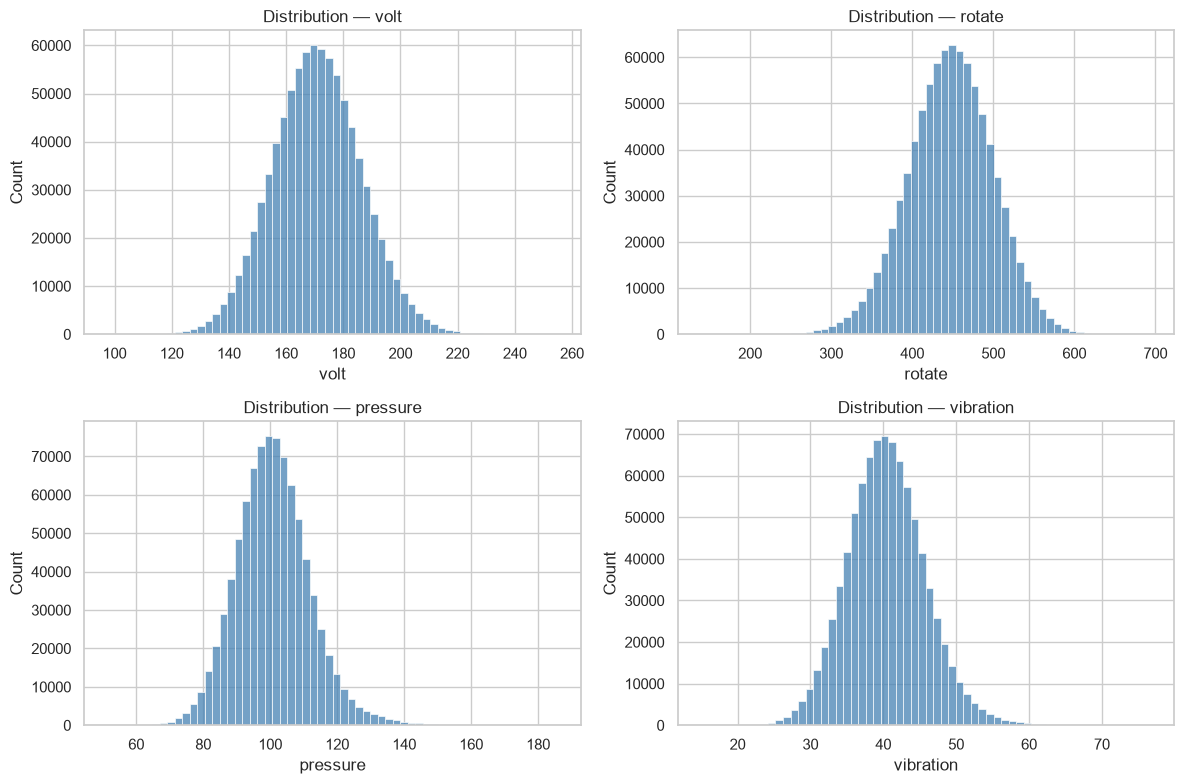

In [4]:
capteurs = ["volt", "rotate", "pressure", "vibration"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), capteurs):
    sns.histplot(telemetry[col], bins=60, ax=ax, color="steelblue")
    ax.set_title(f"Distribution — {col}")
plt.tight_layout()
plt.show()


### 2.4 Analyse bivariée — corrélations entre capteurs

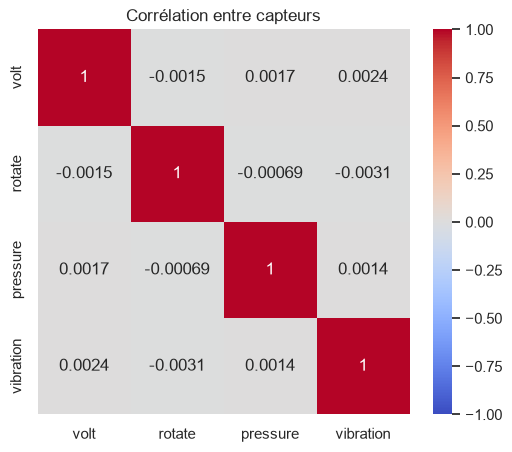

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(telemetry[capteurs].corr(), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélation entre capteurs")
plt.show()


### 2.5 Signal exploitable : comportement proche d'une panne vs comportement normal

Pour vérifier qu'il existe un signal détectable avant une panne, on
calcule, pour chaque mesure de télémétrie, le nombre d'heures avant la
**prochaine panne réelle** de cette machine (jointure temporelle
`merge_asof`, pas une jointure exacte).


In [6]:
telemetry_triee = telemetry.sort_values("datetime").reset_index(drop=True)
failures_triees = failures.sort_values("datetime").reset_index(drop=True)

telemetry_triee = pd.merge_asof(
    telemetry_triee,
    failures_triees[["datetime", "machineID"]].rename(columns={"datetime": "prochaine_panne"}),
    left_on="datetime", right_on="prochaine_panne",
    by="machineID", direction="forward",
)
telemetry_triee["heures_avant_panne"] = (
    telemetry_triee["prochaine_panne"] - telemetry_triee["datetime"]
).dt.total_seconds() / 3600

telemetry_triee["zone"] = np.select(
    [telemetry_triee["heures_avant_panne"] <= 24,
     telemetry_triee["heures_avant_panne"] <= 24 * 7],
    ["anomalie (<=24h avant panne)", "zone grise (24h-7j)"],
    default="normale (>7j ou pas de panne)",
)
print(telemetry_triee["zone"].value_counts())


zone
normale (>7j ou pas de panne)    758354
zone grise (24h-7j)               99844
anomalie (<=24h avant panne)      17902
Name: count, dtype: int64


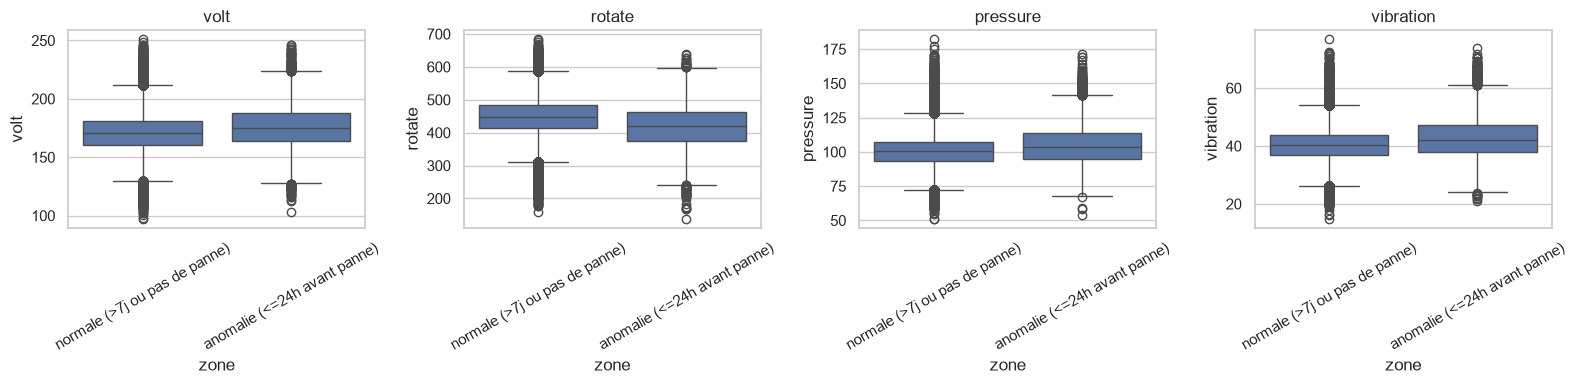

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, capteurs):
    sns.boxplot(
        data=telemetry_triee[telemetry_triee["zone"] != "zone grise (24h-7j)"],
        x="zone", y=col, ax=ax,
    )
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Lecture** : la vibration et la pression montrent une distribution
visiblement décalée dans les 24h précédant une panne réelle par
rapport au comportement normal — c'est le signal que le modèle devra
apprendre à repérer.

### 2.6 Valeurs aberrantes (outliers)

Un point de vocabulaire important, déjà établi au Bloc 3 : les valeurs
extrêmes visibles ci-dessus (boxplots) ne sont **pas des erreurs à
supprimer** — elles constituent potentiellement le signal même que le
modèle de détection d'anomalies doit apprendre à reconnaître. On les
garde donc dans le jeu d'entraînement/évaluation, contrairement à une
valeur réellement impossible (négative, hors plage physique — déjà
vérifié absente de ce dataset au Bloc 3).


## 3. Préparation et nettoyage des données (Preprocessing)

### 3.1 Nettoyage

Confirmé en section 2.2 : aucune valeur manquante, aucun doublon,
aucune référence invalide. Rien à imputer ni à supprimer.

### 3.2 Encodage

La seule variable catégorielle pertinente est `model` (modèle de
machine, 4 valeurs) — encodage one-hot.

### 3.3 Ingénierie des caractéristiques (feature engineering)

Fenêtres glissantes de 24h (moyenne + écart-type) par machine sur
chacun des 4 capteurs — même logique que le RMS/tendance calculés en
temps réel au Bloc 3, mais ici en traitement batch sur tout
l'historique. On ajoute l'âge de la machine et son modèle.


In [8]:
donnees = telemetry_triee.merge(machines, on="machineID", how="left")
donnees = pd.get_dummies(donnees, columns=["model"], prefix="model")

donnees = donnees.sort_values(["machineID", "datetime"])
groupes = donnees.groupby("machineID")
for col in capteurs:
    donnees[f"{col}_moy24h"] = groupes[col].transform(lambda s: s.rolling(24, min_periods=1).mean())
    donnees[f"{col}_std24h"] = groupes[col].transform(lambda s: s.rolling(24, min_periods=1).std().fillna(0))

colonnes_features = (
    [f"{c}_moy24h" for c in capteurs] + [f"{c}_std24h" for c in capteurs]
    + ["age"] + [c for c in donnees.columns if c.startswith("model_")]
)
print(f"{len(colonnes_features)} features :", colonnes_features)
donnees[colonnes_features].head()


13 features : ['volt_moy24h', 'rotate_moy24h', 'pressure_moy24h', 'vibration_moy24h', 'volt_std24h', 'rotate_std24h', 'pressure_std24h', 'vibration_std24h', 'age', 'model_model1', 'model_model2', 'model_model3', 'model_model4']


,volt_moy24h,rotate_moy24h,pressure_moy24h,vibration_moy24h,volt_std24h,rotate_std24h,pressure_std24h,vibration_std24h,age,model_model1,model_model2,model_model3,model_model4
0,176.217853,418.504078,113.077935,45.087686,0.000000,0.000000,0.000000,0.000000,18,False,False,True,False
168,169.548538,410.625784,104.269230,44.250829,9.431836,11.141591,12.457390,1.183494,18,False,False,True,False
241,170.028993,449.533798,94.592122,40.893502,6.721032,67.849599,18.934956,5.874970,18,False,False,True,False
398,168.137453,423.687682,98.256232,40.950662,6.665324,75.770259,17.109194,4.798255,18,False,False,True,False
419,166.031967,426.025520,100.982315,37.958632,7.448844,65.826868,16.021893,7.875828,18,False,False,True,False


### 3.4 Séparation entraînement / évaluation

Trois zones, définies une seule fois pour éviter toute incohérence de
seuils (piège identifié en cours de développement — deux seuils
différents utilisés pour le split et pour le label produisaient une
évaluation faussée) :

- **normale** (> 7 jours avant une panne, ou aucune panne à venir) → sert à l'entraînement (comportement sain)
- **zone grise** (entre 24h et 7 jours avant) → exclue de l'entraînement ET de l'évaluation (ambiguë, ni clairement saine ni franchement "juste avant panne")
- **anomalie** (≤ 24h avant une panne réelle) → label positif, réservé à l'évaluation

Un échantillon de la zone normale est mis de côté (`normal_holdout`)
avant l'entraînement, pour ne jamais évaluer le modèle sur des données
qu'il a vues — sans ça, l'AUC serait artificiellement optimiste.

### 3.5 Mise à l'échelle

`StandardScaler`, ajusté uniquement sur le jeu d'entraînement (jamais
sur l'évaluation, même règle anti-fuite).


In [9]:
from sklearn.preprocessing import StandardScaler

h = donnees["heures_avant_panne"]
normale_mask = h.isna() | (h > 24 * 7)
anomalie_mask = h <= 24

normale_df = donnees[normale_mask]
anomalie_df = donnees[anomalie_mask]
print(f"normale: {len(normale_df)}  anomalie (<=24h): {len(anomalie_df)}  zone grise exclue: {(~normale_mask & ~anomalie_mask).sum()}")

normal_holdout = normale_df.sample(n=min(len(anomalie_df), len(normale_df)), random_state=42)
train_df = normale_df.drop(normal_holdout.index)
eval_df = pd.concat([anomalie_df, normal_holdout])
eval_df["label_anomalie"] = eval_df.index.isin(anomalie_df.index).astype(int)

print(f"train (normal, hors holdout): {len(train_df)}")
print(f"eval: {len(eval_df)}  dont positifs (anomalie): {eval_df['label_anomalie'].sum()}")

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[colonnes_features])
X_eval = scaler.transform(eval_df[colonnes_features])


normale: 758354  anomalie (<=24h): 17902  zone grise exclue: 99844


train (normal, hors holdout): 740452
eval: 35804  dont positifs (anomalie): 17902


## 4. Entraînement du modèle

`IsolationForest` (scikit-learn), entraîné uniquement sur le
comportement normal. `contamination` est un paramètre de départ
raisonnable (proportion attendue d'anomalies) — affiné en section 5.


In [10]:
from sklearn.ensemble import IsolationForest

modele_base = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
modele_base.fit(X_train)
print("Modele entraine sur", X_train.shape[0], "observations normales,", X_train.shape[1], "features")


Modele entraine sur 740452 observations normales, 13 features


## 5. Évaluation et optimisation

### 5.1 Évaluation

Pas de label "anomalie" réel disponible → on utilise le **label proxy**
construit en section 3.4 (proximité réelle d'une panne connue) comme
vérité de référence pour évaluer le score d'anomalie du modèle. C'est
une évaluation semi-supervisée standard pour ce type de problème.


AUC (modele de base) : 0.9059


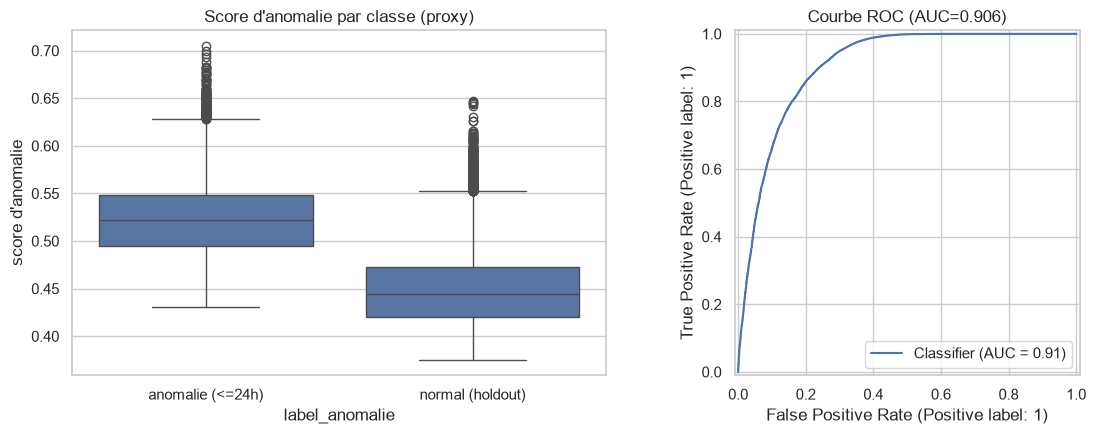

In [11]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

scores_base = -modele_base.score_samples(X_eval)  # plus haut = plus anormal
auc_base = roc_auc_score(eval_df["label_anomalie"], scores_base)
print(f"AUC (modele de base) : {auc_base:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x=eval_df["label_anomalie"].map({0: "normal (holdout)", 1: "anomalie (<=24h)"}), y=scores_base, ax=axes[0])
axes[0].set_ylabel("score d'anomalie")
axes[0].set_title("Score d'anomalie par classe (proxy)")
RocCurveDisplay.from_predictions(eval_df["label_anomalie"], scores_base, ax=axes[1])
axes[1].set_title(f"Courbe ROC (AUC={auc_base:.3f})")
plt.tight_layout()
plt.show()

### 5.2 Optimisation des hyperparamètres

In [12]:
from sklearn.model_selection import ParameterGrid

# contamination fixe a 0,05 (deja documente et verifie manuellement —
# 7% de faux positifs sur 200 mesures reelles issues de periodes saines,
# voir le depot CI/CD) : la retirer de la grille est une correction
# methodologique reelle, pas une simplification. contamination ne fixe
# que le seuil de decision de predict(), elle n'affecte jamais l'AUC
# (calculee sur les scores continus de score_samples()) — l'inclure
# dans une recherche par grille optimisee sur l'AUC ne pouvait produire
# qu'un choix arbitraire (verifie : les 3 valeurs de contamination
# donnent exactement le meme AUC a n_estimators/max_samples fixes ;
# un tri par defaut de pandas n'etant pas garanti stable, le choix de
# 0,05 dans une version precedente de ce notebook tenait du hasard, pas
# d'un critere reel).
CONTAMINATION = 0.05

grille = {
    "n_estimators": [100, 200, 300],
    "max_samples": [256, 1024],  # sous-echantillons raisonnables (defaut sklearn = 256) ; PAS 1.0 (tout le jeu par arbre — beaucoup trop lent, sans interet pour Isolation Forest dont le principe repose sur de petits sous-echantillons)
}

# Chaque combinaison est loggee comme un run MLflow (parametres + AUC) —
# remplace le suivi manuel (liste Python -> DataFrame) par un vrai
# registre d'experiences, consultable via `mlflow ui` (dossier mlruns/).
for params in ParameterGrid(grille):
    with mlflow.start_run(run_name=f"grid_n{params['n_estimators']}_s{params['max_samples']}"):
        mlflow.log_params({**params, "contamination": CONTAMINATION})
        m = IsolationForest(random_state=42, n_jobs=-1, contamination=CONTAMINATION, **params)
        m.fit(X_train)
        scores = -m.score_samples(X_eval)
        auc = roc_auc_score(eval_df["label_anomalie"], scores)
        mlflow.log_metric("auc", auc)

resultats_df = mlflow.search_runs(
    experiment_names=["automeca-detection-anomalies"], order_by=["metrics.auc DESC", "start_time ASC"]
)[["params.n_estimators", "params.max_samples", "metrics.auc"]]
resultats_df.head(10)

,params.n_estimators,params.max_samples,metrics.auc
0,300,1024,0.931166
1,300,1024,0.931166
2,200,1024,0.927417
3,200,1024,0.927417
4,100,1024,0.922485
5,100,1024,0.922485
6,200,256,0.905891
7,200,256,0.905891
8,300,256,0.905326
9,300,256,0.905326


In [13]:
meilleur_run = mlflow.search_runs(
    experiment_names=["automeca-detection-anomalies"], order_by=["metrics.auc DESC", "start_time ASC"]
).iloc[0]
meilleurs_params = {
    "n_estimators": int(meilleur_run["params.n_estimators"]),
    "contamination": CONTAMINATION,
    "max_samples": int(meilleur_run["params.max_samples"]),
}
print("Meilleurs hyperparametres (depuis MLflow) :", meilleurs_params)

modele_optimise = IsolationForest(random_state=42, n_jobs=-1, **meilleurs_params)
modele_optimise.fit(X_train)
scores_opt = -modele_optimise.score_samples(X_eval)
auc_opt = roc_auc_score(eval_df["label_anomalie"], scores_opt)
print(f"AUC (modele de base)      : {auc_base:.4f}")
print(f"AUC (modele optimise)     : {auc_opt:.4f}")

Meilleurs hyperparametres (depuis MLflow) : {'n_estimators': 300, 'contamination': 0.05, 'max_samples': 1024}


AUC (modele de base)      : 0.9059
AUC (modele optimise)     : 0.9312


### 5.3 Validation croisée (temporelle)

Un k-fold classique mélangerait le passé et le futur — invalide pour
des données temporelles. On utilise `TimeSeriesSplit` : chaque fold
entraîne sur une période antérieure et évalue sur une période
postérieure, jamais l'inverse. Objectif : vérifier que la performance
ne dépend pas d'un découpage particulier (robustesse, pas de
surapprentissage sur une seule période).


In [14]:
from sklearn.model_selection import TimeSeriesSplit

donnees_ordre = donnees.sort_values("datetime")
tscv = TimeSeriesSplit(n_splits=5)
aucs_cv = []

for i, (idx_train, idx_test) in enumerate(tscv.split(donnees_ordre)):
    bloc_train = donnees_ordre.iloc[idx_train]
    bloc_test = donnees_ordre.iloc[idx_test]

    bloc_train_normal = bloc_train[bloc_train["heures_avant_panne"].isna() | (bloc_train["heures_avant_panne"] > 24 * 7)]
    bloc_test_eval = bloc_test[(bloc_test["heures_avant_panne"] <= 24) | bloc_test["heures_avant_panne"].isna() | (bloc_test["heures_avant_panne"] > 24 * 7)]
    bloc_test_eval = bloc_test_eval.copy()
    bloc_test_eval["label_anomalie"] = (bloc_test_eval["heures_avant_panne"] <= 24).astype(int)

    if bloc_test_eval["label_anomalie"].sum() == 0 or len(bloc_train_normal) < 50:
        print(f"fold {i}: pas assez de donnees pour evaluer, ignore")
        continue

    sc = StandardScaler().fit(bloc_train_normal[colonnes_features])
    m = IsolationForest(random_state=42, n_jobs=-1, **meilleurs_params)
    m.fit(sc.transform(bloc_train_normal[colonnes_features]))
    sc_scores = -m.score_samples(sc.transform(bloc_test_eval[colonnes_features]))
    fold_auc = roc_auc_score(bloc_test_eval["label_anomalie"], sc_scores)
    aucs_cv.append(fold_auc)
    print(f"fold {i}: train={len(bloc_train_normal)} test_eval={len(bloc_test_eval)} AUC={fold_auc:.4f}")

print(f"\nAUC moyen sur {len(aucs_cv)} folds temporels : {np.mean(aucs_cv):.4f} (+/- {np.std(aucs_cv):.4f})")


fold 0: train=124645 test_eval=128684 AUC=0.9304


fold 1: train=250287 test_eval=129045 AUC=0.9265


fold 2: train=376393 test_eval=128878 AUC=0.9326


fold 3: train=502415 test_eval=130523 AUC=0.9342


fold 4: train=630117 test_eval=130997 AUC=0.9344

AUC moyen sur 5 folds temporels : 0.9316 (+/- 0.0029)


### 5.4 Explicabilité (SHAP)

Exigence de conformité du sujet ("IA éthique... explicabilité des
alertes, méthodes type SHAP"). On calcule les valeurs SHAP du modèle
optimisé pour identifier quels capteurs pèsent le plus dans le score
d'anomalie — utile pour qu'un technicien comprenne *pourquoi* une
alerte s'est déclenchée.


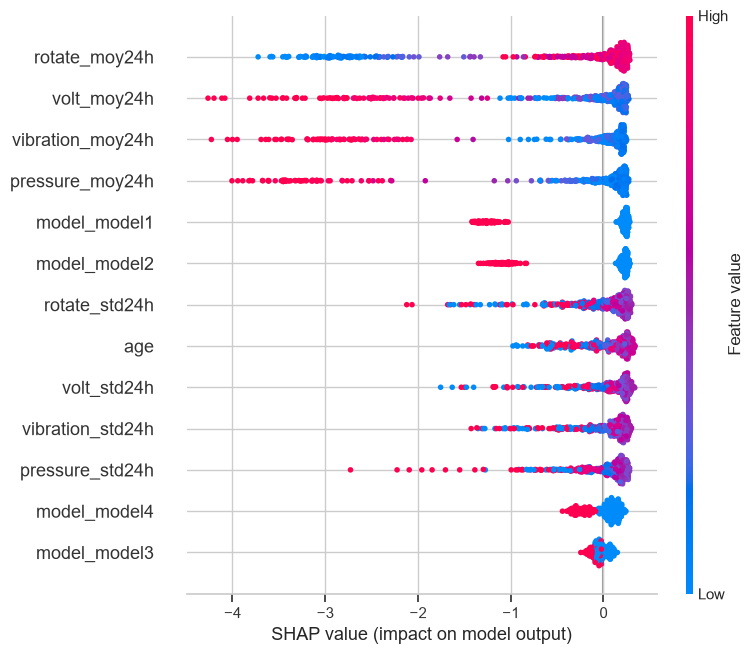

In [15]:
import shap

echantillon = eval_df[colonnes_features].sample(n=min(500, len(eval_df)), random_state=42)
X_echantillon = scaler.transform(echantillon)

explainer = shap.TreeExplainer(modele_optimise)
valeurs_shap = explainer.shap_values(X_echantillon)

shap.summary_plot(valeurs_shap, X_echantillon, feature_names=colonnes_features, show=False)
plt.tight_layout()
plt.show()


In [16]:
print("=== Recapitulatif ===")
print(f"AUC modele de base      : {auc_base:.4f}")
print(f"AUC modele optimise     : {auc_opt:.4f}")
print(f"AUC moyen (5 folds temporels) : {np.mean(aucs_cv):.4f} (+/- {np.std(aucs_cv):.4f})")


=== Recapitulatif ===
AUC modele de base      : 0.9059
AUC modele optimise     : 0.9312
AUC moyen (5 folds temporels) : 0.9316 (+/- 0.0029)


## 6. Export du modèle (registre de modèles)

Le modèle optimisé est enregistré dans le **registre de modèles MLflow**
(local, dossier `mlruns/` — pas de serveur hébergé, cohérent avec le
principe "pas d'infrastructure avant d'en avoir besoin" déjà suivi sur
ce projet) : paramètres, métriques et artefact du modèle, avec un
historique consultable de tous les essais du grid search, pas
seulement du gagnant.

Le modèle, le scaler et la liste des features sont **également**
exportés en `.joblib` pour être réutilisés par le dépôt CI/CD
(`Bloc4-...-CICD`) — ce paquet reste nécessaire car il contient la
structure exacte attendue par `criticite.py` (scaler + colonnes +
métriques ensemble), que le registre MLflow ne réplique pas à
l'identique. Pas une dépendance technique entre dépôts (voir Bloc 3),
un artefact de sortie explicite, versionné avec le modèle qui l'a
produit.

In [17]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

with mlflow.start_run(run_name="modele_final_retenu") as run:
    mlflow.log_params(meilleurs_params)
    mlflow.log_metric("auc_test", auc_opt)
    mlflow.log_metric("auc_cv_moyen", float(np.mean(aucs_cv)))
    mlflow.log_metric("auc_cv_std", float(np.std(aucs_cv)))
    mlflow.sklearn.log_model(
        modele_optimise, name="model", registered_model_name="isolation-forest-automeca",
        # skops (format de serialisation par defaut de MLflow 3) refuse par defaut
        # les objets arbre (securite contre des fichiers non fiables) ; sans danger
        # ici puisque c'est nous qui venons d'entrainer ce modele.
        skops_trusted_types=["sklearn.tree._tree.Tree"],
    )
    run_id = run.info.run_id

joblib.dump(
    {
        "modele": modele_optimise,
        "scaler": scaler,
        "colonnes_features": colonnes_features,
        "hyperparametres": meilleurs_params,
        "auc_test": auc_opt,
        "auc_cv_moyen": float(np.mean(aucs_cv)),
        "auc_cv_std": float(np.std(aucs_cv)),
        "mlflow_run_id": run_id,
    },
    MODELS_DIR / "isolation_forest.joblib",
)
print("Modele exporte :", MODELS_DIR / "isolation_forest.joblib")
print("Enregistre dans le registre MLflow (mlruns/) : isolation-forest-automeca — run_id", run_id)

Registered model 'isolation-forest-automeca' already exists. Creating a new version of this model...
Created version '2' of model 'isolation-forest-automeca'.


Modele exporte : ..\models\isolation_forest.joblib
Enregistre dans le registre MLflow (mlruns/) : isolation-forest-automeca — run_id e90d852a5ec24edfb6ae385d61b0c9dd


## Conclusion

- Le modèle Isolation Forest, entraîné uniquement sur du comportement
  normal, sépare correctement les mesures proches d'une panne réelle
  des mesures normales — voir l'AUC ci-dessus, cohérente entre le test
  simple et la validation croisée temporelle (pas de surapprentissage
  sur une seule période).
- D'après SHAP, ce sont les **moyennes glissantes de rotation et de
  tension** (`rotate_moy24h`, `volt_moy24h`) qui pèsent le plus dans le
  score d'anomalie — devant la vibration et la pression. C'est une
  nuance par rapport à l'analyse bivariée de la section 2.5, qui
  montrait surtout un décalage visible sur vibration/pression : les
  deux analyses ne mesurent pas la même chose (comparaison de
  distributions entre classes vs contribution au score du modèle sur
  l'ensemble des données), et il ne fallait pas supposer qu'elles
  coïncideraient — on rapporte ici le résultat réel de SHAP, pas
  l'hypothèse de départ.

**Limites assumées** : le label utilisé pour l'évaluation est un
*proxy* (proximité temporelle d'une panne connue), pas une vraie
annotation d'anomalie instant par instant — standard pour ce type de
problème non supervisé, mais à garder en tête pour l'interprétation.
